<div style="text-align:center;">
    <h1>Branch and Bound for flowshop</h1>
</div>

In [7]:
import matplotlib.pyplot as plt

References:
- This paper : https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&cad=rja&uact=8&ved=2ahUKEwiI7rOSz9GEAxWVVKQEHRNtCi8QFnoECBoQAQ&url=https%3A%2F%2Fcore.ac.uk%2Fdownload%2Fpdf%2F234676937.pdf&usg=AOvVaw1JmzcyyyqCjFnAwT-OBtHd&opi=89978449

- This youtube video : https://www.youtube.com/watch?v=Q58zRyoa4IE&t=2838s

# Implementing the flowshop with branch and bound class

In [1]:
import copy

class FlowShopBB:
    def __init__(self, jobs_list:list):
        self.jobs_list = jobs_list
        self.upper_bound = self.comp_ub(jobs_list)
        self.seq_star = None
        self.debug = False
        self.array_make_span=[]



    #compute inital upper bound , to improve later ...
    def comp_ub(self, jobs_list:list):
        upper_bound = 0
        for j in range(len(jobs_list[0])):
            for i in range(len(jobs_list)):
                upper_bound += jobs_list[i][j]
        return upper_bound

    #compute the lower bound of the makespan for a partial sequence given its gantt cumule
    def lower_bound(self, jobs_sequence:list, jobs_seq_cumule:list, previous_cumul:list=None):
        nb_machines = len(self.jobs_list[0])
        lb = 0

        if(len(self.jobs_list) - len(jobs_sequence) != 0):
            remaining_time = [0] * (len(self.jobs_list) - len(jobs_sequence)) # the number of remaining jobs
        else:
            remaining_time = [0] # this needs to be a list for the min() function

        for machine_index in range( nb_machines ):
            cumulative_time_to_machine = jobs_seq_cumule[machine_index]
            remaining_machine_time = 0

            counter = 0
            for i in range(len(self.jobs_list)):
                if i not in jobs_sequence:
                    remaining_machine_time += self.jobs_list[i][machine_index]
                    remaining_time[counter] = 0
                    for j in range(machine_index + 1, nb_machines):
                        remaining_time[counter] += self.jobs_list[i][j]
                    counter += 1

                lb_machine = cumulative_time_to_machine + remaining_machine_time + min(remaining_time)
                lb = max(lb, lb_machine)

        return lb

    # utility function that returns the gantt cumule based on a job execution times and a previous gantt cumule
    def cumulate(self, job:list, previous_cumul=None):
        res = [0] * len(job)

        if(previous_cumul==None):
            res[0] = job[0]
            for i in range(1, len(job)):
                res[i] = res[i-1] + job[i]
        else:
            res[0] = previous_cumul[0] + job[0]
            for i in range(1, len(job)):
                res[i] = max(res[i-1], previous_cumul[i]) + job[i]

        return res

    # utility function that computes the gantt cumule given only a job sequence (not used in the algorithm due to inneficiency
    # dynamic programming with cumulate is used instead ...)
    def cumulate_seq(self, seq:list):
        cumulated = None
        for i in seq:
            cumulated = self.cumulate(self. jobs_list[i], cumulated)

        return cumulated

    #branch and bound
    def bb(self, job_seq:list, previous_cumul:list):
        if len(job_seq) == len(self.jobs_list): #it's a complete sequence
            if previous_cumul[-1] < self.upper_bound:
                self.seq_star = copy.deepcopy(job_seq)
                self.upper_bound = previous_cumul[-1]
                self.array_make_span.append(previous_cumul[-1])
                if(self.debug == True):
                    print("new seq_star :", self.seq_star)
                    print("new makespan :", previous_cumul[-1])
                    print("=====================================")
        else:
            augmented_job_seqs = []
            for i in range(len(self. jobs_list)):
                if i not in job_seq:
                    augmented_partial_set:list = (copy.deepcopy(job_seq))
                    augmented_partial_set.append(i)
                    cumu = self.cumulate(self.jobs_list[i], previous_cumul)
                    augmented_job_seqs.append( ( self.lower_bound(augmented_partial_set, cumu), augmented_partial_set, cumu ) )


            ordered_augmented_job_seqs = sorted(augmented_job_seqs)

            for lb_seq_cumu_tuple in ordered_augmented_job_seqs:
                lb = lb_seq_cumu_tuple[0]
                seq = lb_seq_cumu_tuple[1]
                cumu = lb_seq_cumu_tuple[2]
                # if the lower bound of the partial sequence is less than the best MakeSpan(self.upper_boun)
                # that we found until now, we develop the branch, otherwise we prune 
                if lb < self.upper_bound:
                    self.bb(seq, cumu)


    #launching the optimization : this function initializes the singleton partial sequences, and calls branch and bound (bb)
    def optim(self, debug=False):
        self.debug = debug
        if (len(self.jobs_list)==1):
            self.seq_star = [0]

        else:
            initial_job_sequences = []
            for i in range(len(self.jobs_list)):
                cumu = self.cumulate(self.jobs_list[i], previous_cumul=None)
                initial_job_sequences.append( ( self.lower_bound([i], cumu), [i], cumu ) )


            ordered_initial_job_sequences = sorted(initial_job_sequences)


            for lb_seq_cumul_tuple in ordered_initial_job_sequences:
                lb = lb_seq_cumul_tuple[0]
                seq = lb_seq_cumul_tuple[1]
                cumu = lb_seq_cumul_tuple[2]
                # if the lower bound of the partial sequence is less than the best MakeSpan(self.upper_boun)
                # that we found until now, we develop the branch, otherwise we prune 
                if lb < self.upper_bound:
                    self.bb(seq, cumu)



# Definition of some utility functions and data structures

## Getting all the instances of Taillard

In [8]:
import time

# class for hodling the data for each instance of the benhmark
class Inst:
    def __init__(self, jobs: int, machines: int, seed: int, ub: int, lb: int, matrix: list[list[int]]):
        self.jobs = jobs
        self.machines = machines
        self.seed = seed
        self.ub = ub
        self.lb = lb
        self.matrix = matrix

# loading the instances from the benchmark file
with open("ben.txt", "r") as f:
    lines = f.readlines()

instances: list[Inst] = []
i = 0
while i < len(lines):
    params = [int(e) for e in lines[1].split()]
    jobs = params[0]
    machines = params[1]
    seed = params[2]
    ub = params[3]
    lb = params[4]

    matrix = [[int(e) for e in line.strip().split()] for line in lines[i+3:i+3+machines]]
    instances.append(Inst(jobs, machines, seed, ub, lb, matrix))
    i+=3+machines

## Function to get the jobs list of one instance

In [9]:
def get_instance(k):
  jobs_list = []
  for i in range(len(instances[k].matrix[0])):
    jobs_list.append([])
    for j in range(len(instances[k].matrix)):
        jobs_list[-1].append(instances[k].matrix[j][i])
  return jobs_list

## Function for plotting exection times and evolution of MakeSpan

In [10]:
def ploting_time_for_each_number_jobs(x_values,y_values):
  plt.plot(x_values, y_values, marker='o')

  # Adding labels and title
  plt.xlabel('number of jobs')
  plt.ylabel('Time (s)')
  plt.title('the execution time for each number of jobs ')

  # Display the graph
  plt.show()


In [11]:
def ploting_make_span_at_each_step(y_values,i):
  plt.plot(y_values, marker='o')

  # Adding labels and title
  plt.xlabel('step')
  plt.ylabel('Make Span')
  plt.title(f'the make span when number of jobs equal to {i}')

  # Display the graph
  plt.show()

## Function for executing branch and bound for an instance

In [12]:
def exec_instance(k):
    jobs_list = get_instance(k)
    
    fs = FlowShopBB(jobs_list)
    print("Starting optim of the 20 jobs ...")
    start = time.time()
    fs.optim(debug=True)
    print("Execution time: ", time.time() - start)
    print("seq_star:", fs.seq_star)
    print("MakeSpan:",fs.cumulate_seq(fs.seq_star)[-1])

# Testing using a small test case

In [26]:
#the jobs list structure, each row "i" is the time of executions of job Ji for every machine Mj
jobs_list = [[5,6,4],
              [8,7,8],
              [7,2,7],
              [3,5,9]]

fs = FlowShopBB(jobs_list)
print("Starting optim of the 4 jobs ...")
start = time.time()

# We launch the optimization by calling the method .opitm()
# setting debug = True let's us print every time the algorithm finds a new best sequence (seq_star) during exploration
# We print at the end the execution time in seconds, the optimal sequence (seq_star) and its Makespan
fs.optim(debug=True) 
print("Execution time: ", time.time() - start)
print("seq_star:", fs.seq_star)
print("MakeSpan:",fs.upper_bound)

Starting optim of the 4 jobs ...
new seq_star : [3, 0, 1, 2]
new makespan : 38
new seq_star : [3, 2, 1, 0]
new makespan : 37
Execution time:  0.0
seq_star: [3, 2, 1, 0]
MakeSpan: 37


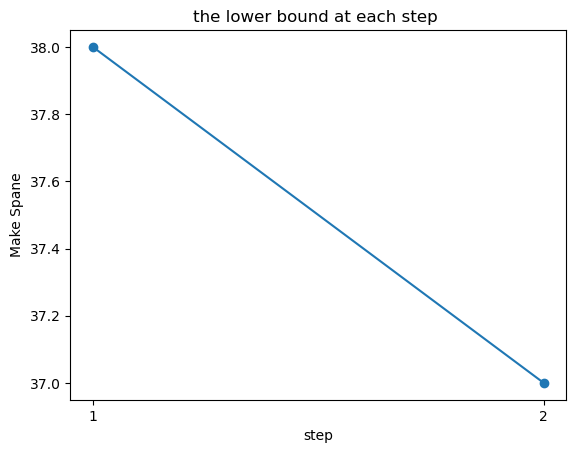

In [16]:
plt.plot([1,2], fs.array_make_span, marker='o')

# Adding labels and title
plt.xlabel('step')
plt.ylabel('Make Spane')
plt.title('the lower bound at each step ')

plt.xticks(range(min([1,2]), max([1,2])+1))
# Display the graph
plt.show()

# Launching the branch and bound for the first Taillard instance for different number of jobs (from 1 to 12)

## Executing and plotting the evolution of MakeSpan during branch and bound

Starting optim of the first 1 jobs ...


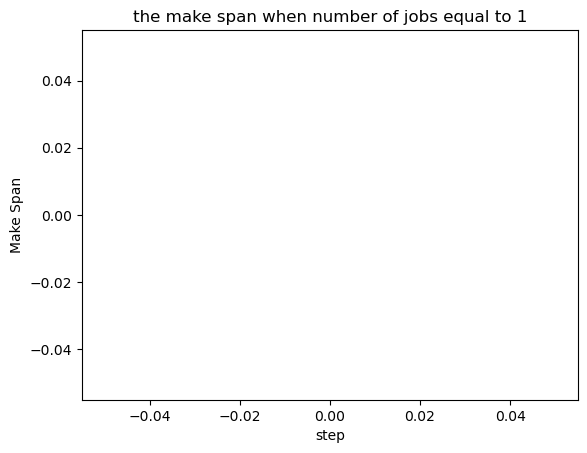

Execution time:  0.0
seq_star: [0]
MakeSpan: 273
Starting optim of the first 2 jobs ...


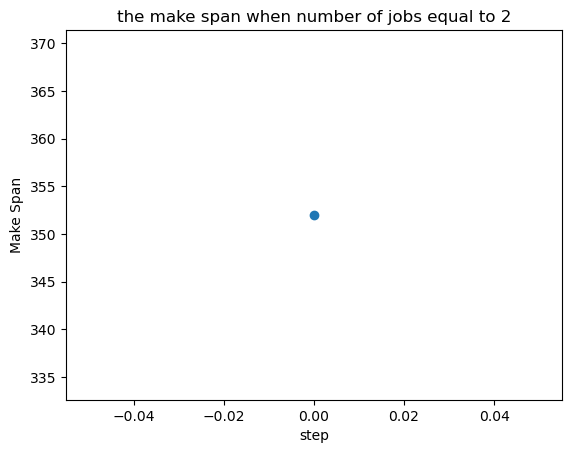

Execution time:  0.0
seq_star: [0, 1]
MakeSpan: 352
Starting optim of the first 3 jobs ...


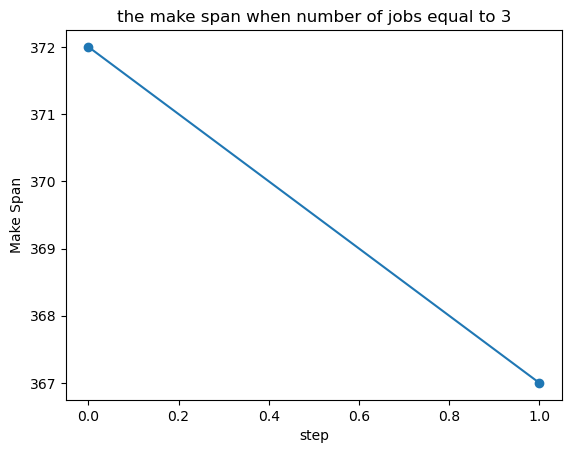

Execution time:  0.0
seq_star: [2, 0, 1]
MakeSpan: 367
Starting optim of the first 4 jobs ...


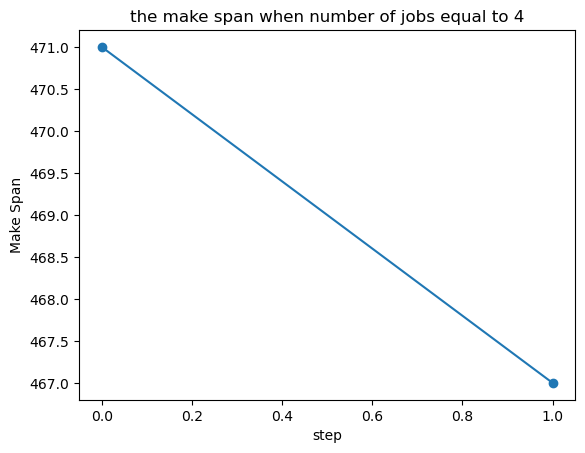

Execution time:  0.002520322799682617
seq_star: [0, 2, 3, 1]
MakeSpan: 467
Starting optim of the first 5 jobs ...


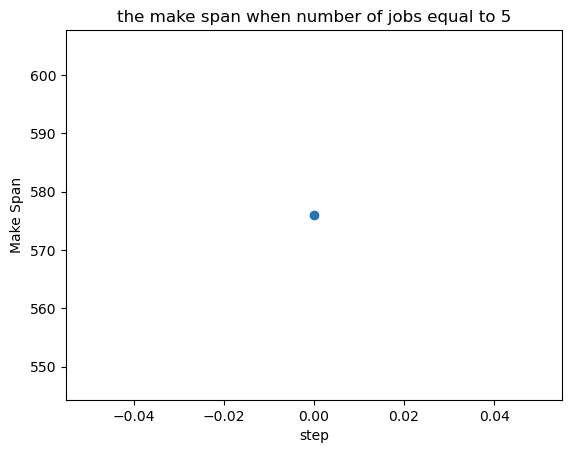

Execution time:  0.01150965690612793
seq_star: [0, 2, 3, 1, 4]
MakeSpan: 576
Starting optim of the first 6 jobs ...


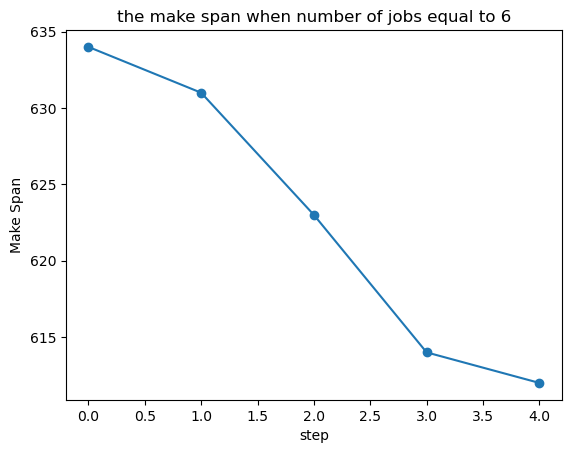

Execution time:  0.016600847244262695
seq_star: [5, 3, 1, 0, 2, 4]
MakeSpan: 612
Starting optim of the first 7 jobs ...


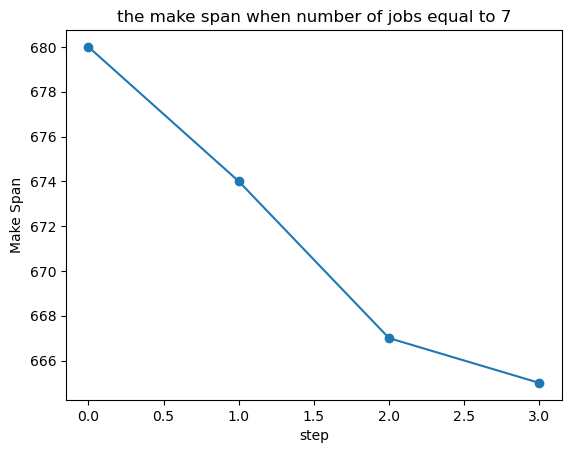

Execution time:  0.054840087890625
seq_star: [5, 3, 1, 0, 2, 4, 6]
MakeSpan: 665
Starting optim of the first 8 jobs ...


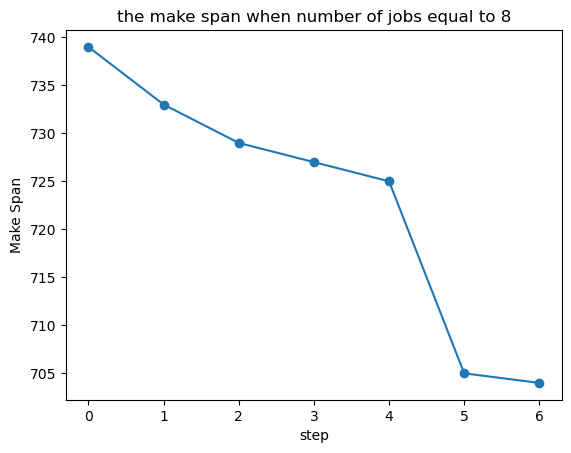

Execution time:  0.1659867763519287
seq_star: [2, 5, 0, 3, 1, 7, 4, 6]
MakeSpan: 704
Starting optim of the first 9 jobs ...


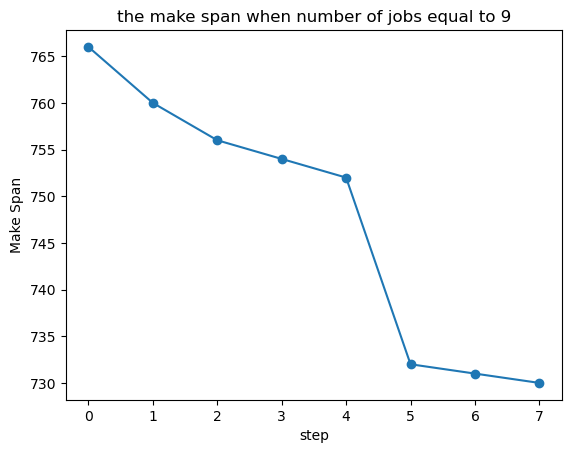

Execution time:  0.3657364845275879
seq_star: [7, 8, 5, 3, 1, 0, 2, 4, 6]
MakeSpan: 730
Starting optim of the first 10 jobs ...


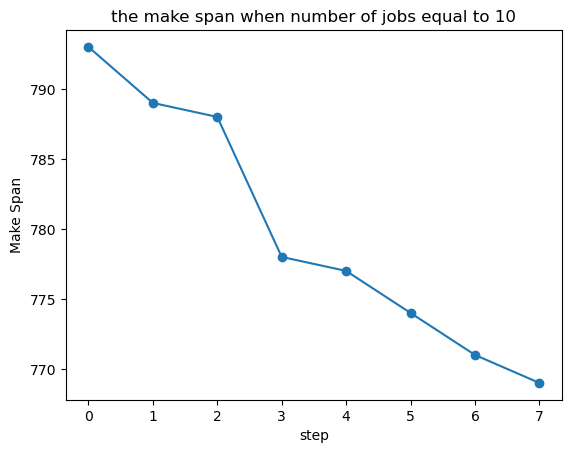

Execution time:  0.8834280967712402
seq_star: [2, 7, 0, 8, 5, 4, 3, 1, 9, 6]
MakeSpan: 769
Starting optim of the first 11 jobs ...


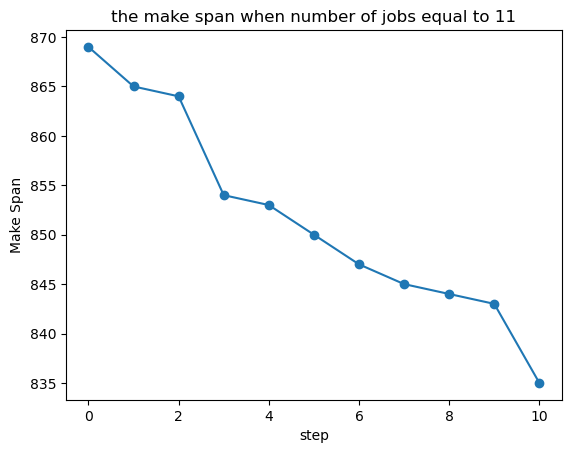

Execution time:  2.556377410888672
seq_star: [8, 7, 2, 5, 3, 1, 0, 4, 6, 10, 9]
MakeSpan: 835
Starting optim of the first 12 jobs ...


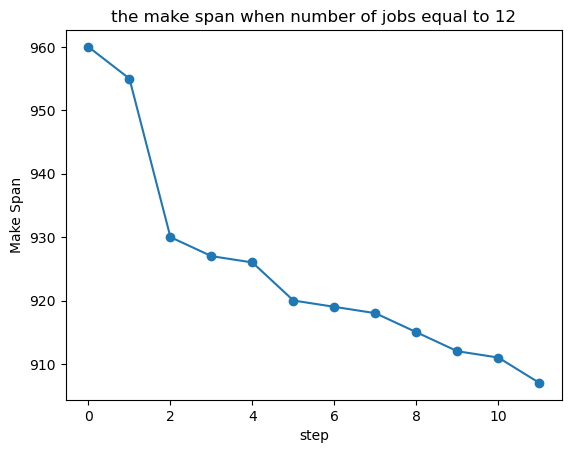

Execution time:  52.327046394348145
seq_star: [8, 7, 2, 5, 6, 10, 0, 4, 3, 1, 9, 11]
MakeSpan: 907


In [20]:
# here we will launch the execution of branch and bound for gradually increasing number of jobs in the first instance
# The execution gets longer as the number of jobs increases, thus we stop it manually once it starts to take too long
jobs_list=get_instance(0)
times=[]
x_values=[]
for i in range(len(jobs_list)):
    local_jobs_list = jobs_list[:i+1]
    print("======================================================")
    print(f"Starting optim of the first {i+1} jobs ...")
    fs = FlowShopBB(local_jobs_list)
    start = time.time()
    fs.optim(False)
    end = time.time() - start
    times.append(end)
    ploting_make_span_at_each_step(fs.array_make_span,i+1)
    print("Execution time: ", end)
    print("seq_star:", fs.seq_star)
    print("MakeSpan:",fs.upper_bound)
    x_values.append(i+1)
    if(i==11) : break

## Plotting the evolution of the execution time for each number of jobs

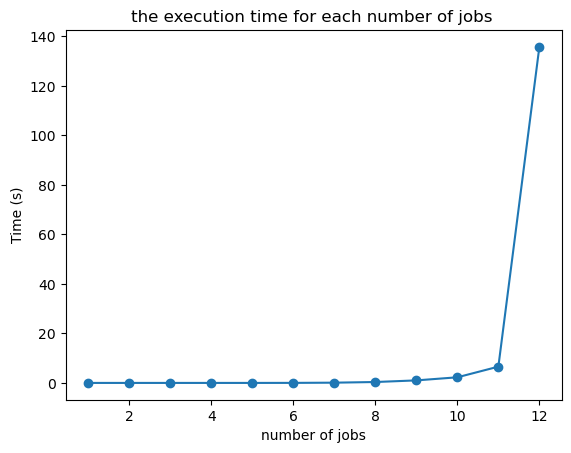

In [11]:
ploting_time_for_each_number_jobs(x_values,times)

# Launching the execution for every instance of Taillard (we stop manually via a `Keyboard Interrupt` when it takes too long)

In [14]:
exec_instance(0)

Starting optim of the 20 jobs ...
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 19, 11, 2, 17, 9]
new makespan : 1370
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 19, 2, 9, 17, 11]
new makespan : 1358
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 19, 2, 17, 11, 9]
new makespan : 1339
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 11, 9, 2, 17, 19]
new makespan : 1324
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 11, 2, 17, 9, 19]
new makespan : 1322
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 2, 17, 11, 9, 19]
new makespan : 1306
new seq_star : [7, 0, 8, 3, 10, 1, 12, 15, 5, 14, 16, 18, 13, 4, 6, 17, 2, 11, 9, 19]
new makespan : 1297


KeyboardInterrupt: 

In [22]:
exec_instance(1)

Starting optim of the 20 jobs ...
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 7, 16, 19, 0, 10, 12, 4, 11, 8, 1]
new makespan : 1457
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 7, 16, 19, 0, 10, 12, 4, 8, 11, 1]
new makespan : 1453
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 7, 16, 19, 0, 10, 12, 8, 4, 11, 1]
new makespan : 1451
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 7, 16, 19, 0, 10, 12, 8, 11, 4, 1]
new makespan : 1434
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 16, 4, 7, 19, 10, 11, 12, 8, 0, 1]
new makespan : 1430
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 16, 4, 7, 19, 11, 12, 8, 0, 10, 1]
new makespan : 1422
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 16, 8, 0, 7, 19, 10, 12, 11, 4, 1]
new makespan : 1420
new seq_star : [13, 5, 17, 18, 9, 6, 2, 15, 14, 3, 16, 8, 0, 10, 12, 11, 7, 19, 4, 1]
new makespan : 1417
new seq_star : [13, 5, 17, 9, 6, 2, 7, 18, 3, 16, 19, 10, 11, 15, 14, 0, 12, 8, 4, 1]
new makespan : 1409
new seq_star

In [13]:
exec_instance(2)

Starting optim of the 20 jobs ...
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 7, 17, 8, 16, 4, 11, 1]
new makespan : 1301
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 7, 17, 8, 16, 11, 4, 1]
new makespan : 1277
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 7, 17, 16, 4, 11, 1, 8]
new makespan : 1262
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 7, 17, 16, 11, 4, 1, 8]
new makespan : 1240
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 17, 7, 4, 11, 8, 16, 1]
new makespan : 1236
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 17, 16, 4, 11, 1, 7, 8]
new makespan : 1233
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 17, 16, 11, 7, 4, 1, 8]
new makespan : 1223
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 17, 16, 11, 4, 1, 8, 7]
new makespan : 1209
new seq_star : [2, 3, 9, 14, 18, 13, 12, 15, 10, 0, 19, 6, 5, 17, 11, 4, 7, 16, 1, 8]
new makespan : 1207
new seq_star

In [11]:
exec_instance(3)

Starting optim of the 20 jobs ...
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 14, 9, 1, 11, 4, 6, 0, 2]
new makespan : 1455
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 14, 9, 1, 11, 6, 0, 4, 2]
new makespan : 1443
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 6, 9, 11, 14, 1, 4, 0, 2]
new makespan : 1440
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 6, 9, 11, 14, 1, 0, 4, 2]
new makespan : 1438
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 6, 9, 0, 4, 11, 14, 1, 2]
new makespan : 1434
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 6, 9, 0, 4, 14, 11, 1, 2]
new makespan : 1430
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 17, 6, 9, 1, 2, 11, 14, 0, 4]
new makespan : 1427
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 14, 9, 1, 11, 4, 6, 0, 2, 17]
new makespan : 1425
new seq_star : [12, 8, 15, 13, 3, 19, 10, 7, 16, 18, 5, 14, 9, 1, 11, 17, 6, 0, 4, 2]
new makespan : 1415
new seq_star

In [12]:
exec_instance(4)

Starting optim of the 20 jobs ...
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 17, 18, 16, 13, 14, 15, 5, 10, 1, 4]
new makespan : 1395
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 17, 18, 16, 13, 14, 15, 5, 1, 4, 10]
new makespan : 1372
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 17, 18, 16, 13, 14, 15, 5, 4, 1, 10]
new makespan : 1360
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 17, 18, 16, 15, 14, 5, 1, 13, 4, 10]
new makespan : 1354
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 17, 18, 16, 15, 14, 5, 1, 4, 13, 10]
new makespan : 1351
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 17, 18, 16, 15, 14, 5, 4, 1, 13, 10]
new makespan : 1338
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 18, 16, 15, 5, 4, 1, 10, 14, 13, 17]
new makespan : 1336
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 6, 18, 16, 1, 15, 4, 5, 17, 10, 14, 13]
new makespan : 1332
new seq_star : [2, 0, 7, 9, 11, 12, 19, 8, 3, 14, 18, 5, 16, 15, 1, 10, 17, 4, 13, 6]
new makespan : 1331
new seq_star

KeyboardInterrupt: 

In [13]:
exec_instance(5)

Starting optim of the 20 jobs ...
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 3, 7, 13, 17, 9, 6, 8, 11, 14, 15, 18, 2]
new makespan : 1272
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 3, 7, 13, 17, 9, 6, 11, 8, 14, 15, 18, 2]
new makespan : 1270
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 3, 7, 6, 11, 13, 17, 9, 14, 15, 8, 18, 2]
new makespan : 1268
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 3, 7, 6, 11, 13, 17, 9, 15, 14, 8, 18, 2]
new makespan : 1262
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 3, 17, 13, 6, 11, 14, 8, 7, 9, 15, 18, 2]
new makespan : 1258
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 3, 6, 7, 11, 13, 17, 9, 15, 14, 8, 18, 2]
new makespan : 1252
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 6, 3, 7, 13, 17, 9, 11, 15, 14, 8, 18, 2]
new makespan : 1249
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 6, 3, 7, 13, 17, 9, 15, 14, 11, 8, 18, 2]
new makespan : 1245
new seq_star : [1, 10, 4, 0, 19, 16, 12, 5, 6, 3, 7, 13, 17, 9, 15, 14, 8, 11, 18, 2]
new makespan : 1241
new seq_star

KeyboardInterrupt: 

In [23]:
exec_instance(6)

Starting optim of the 20 jobs ...
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 11, 14, 17, 7, 10, 5, 2, 6]
new makespan : 1353
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 11, 14, 2, 7, 10, 5, 6, 17]
new makespan : 1327
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 11, 14, 2, 10, 5, 7, 17, 6]
new makespan : 1317
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 11, 2, 14, 10, 5, 7, 17, 6]
new makespan : 1315
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 11, 2, 7, 10, 5, 17, 6, 14]
new makespan : 1312
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 14, 7, 10, 5, 2, 6, 17, 11]
new makespan : 1306
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 14, 7, 5, 10, 2, 6, 17, 11]
new makespan : 1302
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 14, 10, 5, 2, 7, 6, 17, 11]
new makespan : 1301
new seq_star : [9, 1, 12, 0, 18, 13, 15, 16, 8, 3, 19, 4, 14, 10, 5, 2, 7, 11, 17, 6]
new makespan : 1291
new seq_star

In [9]:
exec_instance(7)

Starting optim of the 20 jobs ...
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 9, 15, 17, 12, 13, 7, 19, 14, 18, 0]
new makespan : 1404
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 9, 15, 17, 12, 13, 7, 19, 18, 0, 14]
new makespan : 1383
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 9, 15, 17, 12, 13, 7, 18, 14, 19, 0]
new makespan : 1324
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 9, 15, 17, 12, 13, 18, 7, 14, 19, 0]
new makespan : 1287
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 9, 15, 17, 12, 18, 14, 13, 7, 19, 0]
new makespan : 1284
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 9, 15, 17, 13, 18, 7, 19, 14, 12, 0]
new makespan : 1271
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 15, 13, 18, 7, 9, 17, 19, 14, 12, 0]
new makespan : 1262
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 15, 18, 7, 9, 13, 17, 19, 14, 12, 0]
new makespan : 1261
new seq_star : [11, 5, 16, 1, 4, 8, 2, 3, 6, 10, 15, 18, 7, 19, 9, 17, 14, 13, 12, 0]
new makespan : 1260
new seq_star

KeyboardInterrupt: 

In [24]:
exec_instance(8)

Starting optim of the 20 jobs ...
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 12, 17, 16, 8, 13, 4, 18]
new makespan : 1305
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 12, 17, 16, 8, 18, 4, 13]
new makespan : 1302
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 12, 17, 16, 13, 18, 8, 4]
new makespan : 1296
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 12, 17, 16, 18, 13, 8, 4]
new makespan : 1293
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 13, 12, 17, 16, 18, 8, 4]
new makespan : 1289
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 17, 16, 12, 18, 13, 8, 4]
new makespan : 1286
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 2, 5, 17, 16, 18, 12, 13, 8, 4]
new makespan : 1285
new seq_star : [3, 1, 7, 15, 6, 14, 11, 9, 19, 0, 10, 17, 16, 5, 13, 12, 18, 2, 8, 4]
new makespan : 1283
new seq_star : [3, 1, 7, 15, 6, 14, 9, 11, 0, 10, 2, 19, 5, 12, 17, 16, 18, 13, 8, 4]
new makespan : 1280
new seq_star

KeyboardInterrupt: 

In [25]:
exec_instance(9)

Starting optim of the 20 jobs ...
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 3, 9, 18, 14, 19, 16, 17, 8, 13]
new makespan : 1206
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 3, 9, 18, 14, 13, 16, 17, 8, 19]
new makespan : 1167
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 3, 9, 19, 18, 8, 17, 13, 16, 14]
new makespan : 1166
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 3, 9, 19, 18, 17, 8, 13, 16, 14]
new makespan : 1159
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 3, 9, 19, 18, 17, 13, 16, 8, 14]
new makespan : 1158
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 16, 9, 18, 17, 13, 14, 3, 19, 8]
new makespan : 1151
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 18, 17, 16, 9, 13, 19, 3, 14, 8]
new makespan : 1143
new seq_star : [6, 10, 4, 12, 11, 15, 5, 0, 1, 7, 2, 18, 17, 9, 13, 19, 16, 3, 14, 8]
new makespan : 1127


KeyboardInterrupt: 